In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import plotly.subplots as sp
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

In [68]:
warnings.simplefilter(action='ignore', category=FutureWarning)
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)

In [70]:
wp = pd.read_csv('C:\\Users\\Lenovo\\Downloads\\world_population.csv',encoding="latin1")
wp.head()
wp.shape
wp.isnull().sum()
print(f'Amount of Duplicates:{wp.duplicated().sum()}')
wp.columns

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Lenovo\\Downloads\\world_population.csv'

In [72]:
wp.sort_values(by = 'Country/Territory',ascending=True)

NameError: name 'wp' is not defined

In [74]:
wp.isnull().sum()

NameError: name 'wp' is not defined

In [76]:
wp.drop(["CCA3","Capital"],axis=1,inplace= True)

NameError: name 'wp' is not defined

In [78]:
wp.head()
wp.tail()
custom_palette = ['#0b3d91', '#e0f7fa', '#228b22', '#1e90ff', '#8B4513', '#D2691E',
'#DAA520', '#556B2F']

fig= px.bar(countries_by_continent,
            x='Continent',
            y='count',
            color='Continent',
            text='count',
            title='Number of Countires by Contitnent',
           color_discrete_sequence = custom_palette )

NameError: name 'wp' is not defined

In [80]:
wp["Rank"]

NameError: name 'wp' is not defined

In [82]:
wp.head().sort_values(by = "Country/Territory",ascending= False)

NameError: name 'wp' is not defined

In [84]:
wp.tail()

NameError: name 'wp' is not defined

In [86]:
wp.tail().sort_values(by='Country/Territory',ascending=True)

NameError: name 'wp' is not defined

In [88]:
pop_22 = wp['2022 Population'].sum()
pop_70 = wp['1970 Population'].sum()

pop_22 - pop_70

NameError: name 'wp' is not defined

In [90]:
countries_by_continent = wp["Continent"].value_counts().reset_index()
countries_by_continent


NameError: name 'wp' is not defined

In [92]:
wp.groupby(by="Continent").count()

NameError: name 'wp' is not defined

### Create the bar chart

In [95]:
fig= px.bar(countries_by_continent,
            x='Continent',
            y='count',
            color='Continent',
            text='count',
            title='Number of Countires by Contitnent',
           color_discrete_sequence = custom_palette )

NameError: name 'countries_by_continent' is not defined

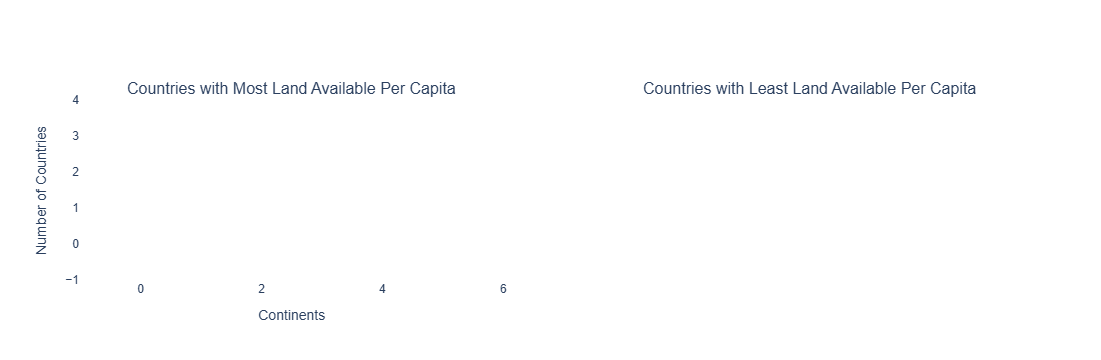

In [97]:
fig.update_layout(
xaxis_title='Continents',
yaxis_title='Number of Countries',
plot_bgcolor='rgba(0,0,0,0)', 
font_family='Arial', 
title_font_size=20 )

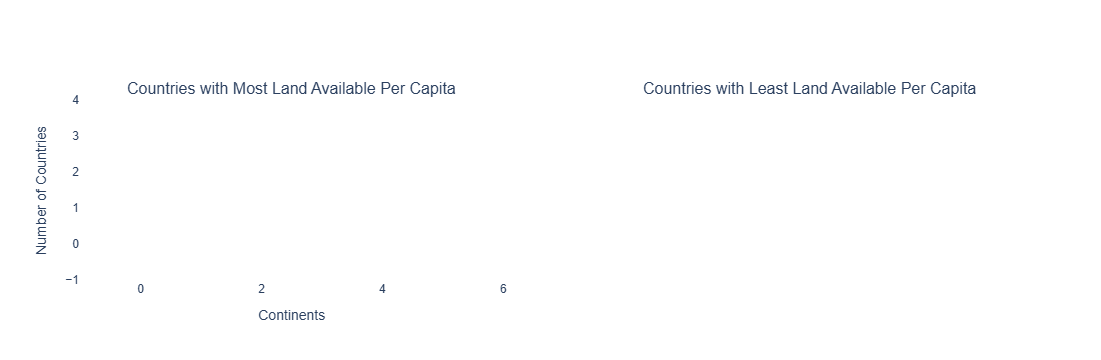

In [99]:
fig.show()

In [101]:
continent_population_percentage = wp.groupby('Continent')['World Population Percentage'].sum().reset_index()
continent_population_percentage

NameError: name 'wp' is not defined

In [103]:
fig = go.Figure(data=[go.Pie(labels=continent_population_percentage['Continent'],
values=continent_population_percentage['World Population Percentage'])])

NameError: name 'continent_population_percentage' is not defined

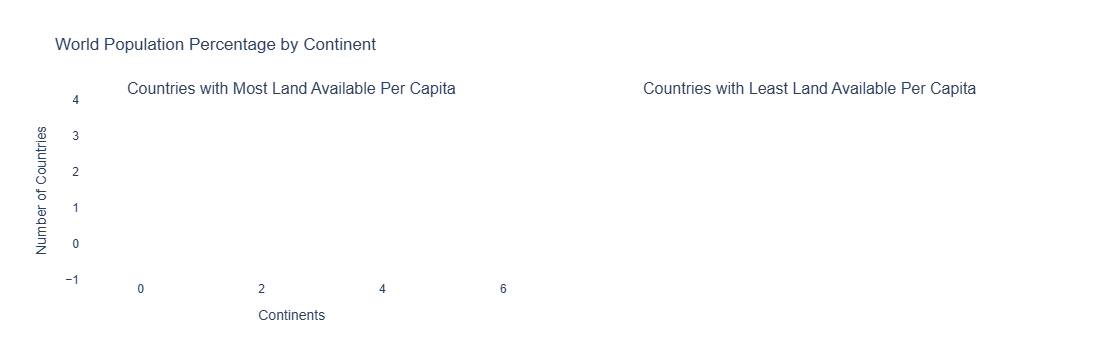

In [105]:
fig.update_layout(
title='World Population Percentage by Continent',
template='plotly',
paper_bgcolor='rgba(255,255,255,0)', 
plot_bgcolor='rgba(255,255,255,0)' 
)

In [106]:
fig.update_traces(marker=dict(colors=custom_palette, line=dict(color='#FFFFFF',
width=1)))
fig.show()

NameError: name 'custom_palette' is not defined

### Melt the DataFrame to have a long format

In [ ]:

wp_melted = wp.melt(id_vars=['Continent'],
value_vars=['2022 Population', '2020 Population', '2015 Population','2010 Population', '2000 Population', '1990 Population','1980 Population',
            '1970 Population'],
var_name='Year',
value_name='Population')

In [ ]:
wp_melted['Year'] = wp_melted['Year'].str.split().str[0].astype(int)
population_by_continent = wp_melted.groupby(['Continent',
'Year']).sum().reset_index()


In [ ]:
fig = px.line(population_by_continent, x='Year', y='Population', color='Continent',
title='Population Trends by Continent Over Time',
labels={'Population': 'Population', 'Year': 'Year'},
color_discrete_sequence=custom_palette)
fig.update_layout(
template='plotly_white',
xaxis_title='Year',
yaxis_title='Population',
font_family='Arial',
title_font_size=20,
)
fig.update_traces(line=dict(width=3))
fig.show()

In [ ]:
features=['1970 Population' ,'2020 Population']
for feature in features:
    fig = px.choropleth(wp,
                        locations='Country/Territory',
                        locationmode='country names',
                        color=feature,
                        hover_name='Country/Territory',
                        template='plotly_white',
                        title = feature)
fig.show()

In [ ]:
growth = (wp.groupby(by='Country/Territory')['2022 Population'].sum()-wp.groupby(by='Country/Territory')
          ['1970 Population'].sum()).sort_values(ascending=False).head(8)

fig=px.bar(x=growth.index,
y=growth.values,
text=growth.values,
color=growth.values,
title='Growth Of Population From 1970 to 2020 (Top 8)',
template='plotly_white')
fig.update_layout(xaxis_title='Country',
yaxis_title='Population Growth')
fig.show()


In [107]:
top_8_populated_countries_1970 = wp.groupby('Country/Territory')['1970 Population'].sum().sort_values(ascending=False).head(8)
top_8_populated_countries_2022 = wp.groupby('Country/Territory')['2022 Population'].sum().sort_values(ascending=False).head(8)

features = {'top_8_populated_countries_1970': top_8_populated_countries_1970,
'top_8_populated_countries_2022': top_8_populated_countries_2022}
for feature_name, feature_data in features.items():
    year = feature_name.split('_')[-1] 
    fig = px.bar(x=feature_data.index,
                 y=feature_data.values,
                 text=feature_data.values,
                 color=feature_data.values,
                 title=f'Top 8 Most Populated Countries ({year})',
                 template='plotly_white')
    fig.update_layout(xaxis_title='Country',
                      yaxis_title='Population Growth')
fig.show()

NameError: name 'wp' is not defined

In [109]:
sorted_df_growth = wp.sort_values(by='Growth Rate', ascending=False)
top_fastest = sorted_df_growth.head(6)
top_slowest = sorted_df_growth.tail(6)

NameError: name 'wp' is not defined

In [111]:
def plot_population_trends(countries):
    n_cols = 2
    n_rows = (len(countries) + n_cols - 1) // n_cols

In [113]:

def plot_population_trends(countries):
    
    n_cols = 2
    n_rows = (len(countries) + n_cols - 1) // n_cols

    fig = sp.make_subplots(rows=n_rows, cols=n_cols, subplot_titles=countries,
                           horizontal_spacing=0.1, vertical_spacing=0.1)

    for i, country in enumerate(countries, start=1):
       
        country_wp = wp[wp['Country/Territory'] == country]

       
        country_melted = country_wp .melt(
            id_vars=['Country/Territory'],
            value_vars=['2022 Population', '2020 Population', '2015 Population',
                        '2010 Population', '2000 Population', '1990 Population',
                        '1980 Population', '1970 Population'],
            var_name='Year',
            value_name='Population'
        )

     
        country_melted['Year'] = country_melted['Year'].str.split().str[0].astype(int)

        
        line_fig = px.line(country_melted, x='Year', y='Population',
                           color='Country/Territory',
                           labels={'Population': 'Population', 'Year': 'Year'},
                           color_discrete_sequence=custom_palette)

       
        row = (i - 1) // n_cols + 1
        col = (i - 1) % n_cols + 1

        for trace in line_fig.data:
            fig.add_trace(trace, row=row, col=col)


    fig.update_layout(
        title='Population Trends of Selected Countries Over Time',
        template='plotly_white',
        font_family='Arial',
        title_font_size=20,
        showlegend=False,
        height=600 * n_rows,  
    )
    fig.update_traces(line=dict(width=3))
    fig.update_xaxes(title_text='Year')
    fig.update_yaxes(title_text='Population')
    fig.show()


In [115]:
fastest = top_fastest[['Country/Territory', 'Growth Rate']].sort_values(by='Growth Rate', ascending=False).reset_index(drop=True)
fastest
plot_population_trends(['Moldova', 'Poland', 'Niger', 'Syria', 'Slovakia', 'DR Congo'])

NameError: name 'top_fastest' is not defined

In [117]:
slowest = top_slowest[['Country/Territory', 'Growth Rate']].sort_values(by='Growth Rate', ascending=False).reset_index(drop=True)
slowest

NameError: name 'top_slowest' is not defined

In [119]:
plot_population_trends(['Latvia', 'Lithuania', 'Bulgaria', 'American Samoa',
'Lebanon', 'Ukraine'])

NameError: name 'wp' is not defined

In [121]:
land_by_country = wp.groupby('Country/Territory')['Area (km²)'].sum().sort_values(ascending=False)
most_land = land_by_country.head(5)
least_land = land_by_country.tail(5)

NameError: name 'wp' is not defined

In [123]:
fig = sp.make_subplots(rows=1, cols=2, subplot_titles=("Countries with Most Land",
                                                       "Countries with Least Land"))
fig.add_trace(go.Bar(x=most_land.index, y=most_land.values, name='Most Land',
                     marker_color=custom_palette[0]), row=1, col=1)
fig.add_trace(go.Bar(x=least_land.index, y=least_land.values, name='Least Land',
                     marker_color=custom_palette[1]), row=1, col=2)
fig.update_layout(title_text="Geographical Distribution of Land Area by Country",
                  showlegend=False,
                  template='plotly_white')
fig.update_yaxes(title_text="Area (km²)", row=1, col=1)
fig.update_yaxes(title_text="Area (km²)", row=1, col=2)
fig.show()


NameError: name 'most_land' is not defined

In [125]:
wp['Area per Person']=wp['Area (km²)'] / wp['2022 Population']
country_area_per_person = wp.groupby('Country/Territory')['Area per Person'].sum()
most_land_available = country_area_per_person.sort_values(ascending=False).head(5)
least_land_available = country_area_per_person.sort_values(ascending=False).tail(5)

NameError: name 'wp' is not defined

In [127]:
fig = sp.make_subplots(rows=1, cols=2, subplot_titles=("Countries with Most Land Available Per Capita",
                                                       "Countries with Least Land Available Per Capita"))
fig.add_trace(go.Bar(x=most_land_available.index, y=most_land_available.values,
                     name='Most Land', marker_color=custom_palette[2]), row=1, col=1)
fig.add_trace(go.Bar(x=least_land_available.index, y=least_land_available.values,
name='Least Land', marker_color=custom_palette[3]), row=1, col=2)
fig.update_layout(title_text="Distribution of Available Land Area by Country Per Capita",
                  showlegend=False,
                  template='plotly_white')
fig.update_yaxes(title_text="Land Available Per Person", row=1, col=1)
fig.update_yaxes(title_text="Land Available Per Person", row=1, col=2)
fig.show()


NameError: name 'most_land_available' is not defined

In [139]:
 world_population = pd.to_xlxs('world_population.csv')

AttributeError: module 'pandas' has no attribute 'to_xlxs'